<a href="https://colab.research.google.com/github/Trishan-Banik/DPCM-and-delta-modulation/blob/main/DPCM_and_delta_modulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DPCM AND DELTA MODULATION SIMULATION
Sampling frequency = 10000 Hz
Duration            = 0.02 seconds
Amplitude           = 1.0


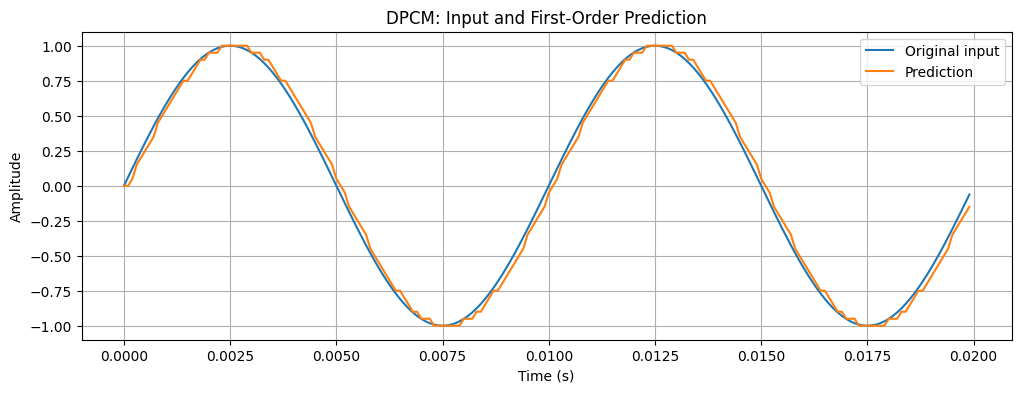

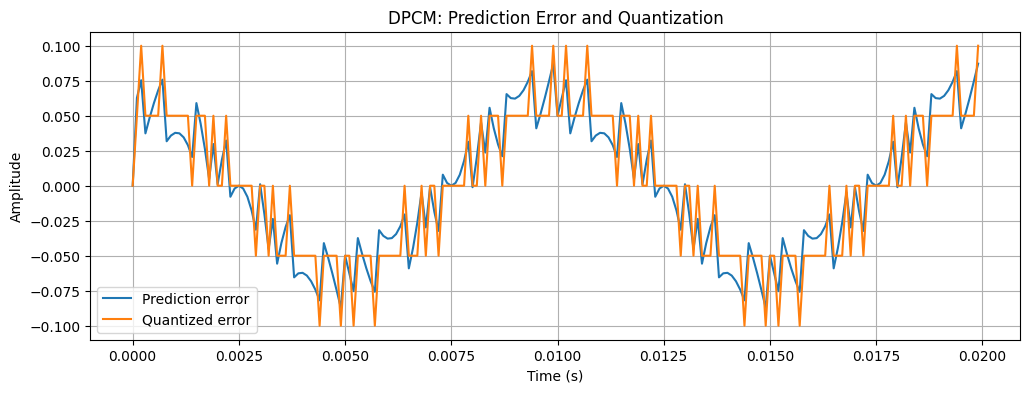

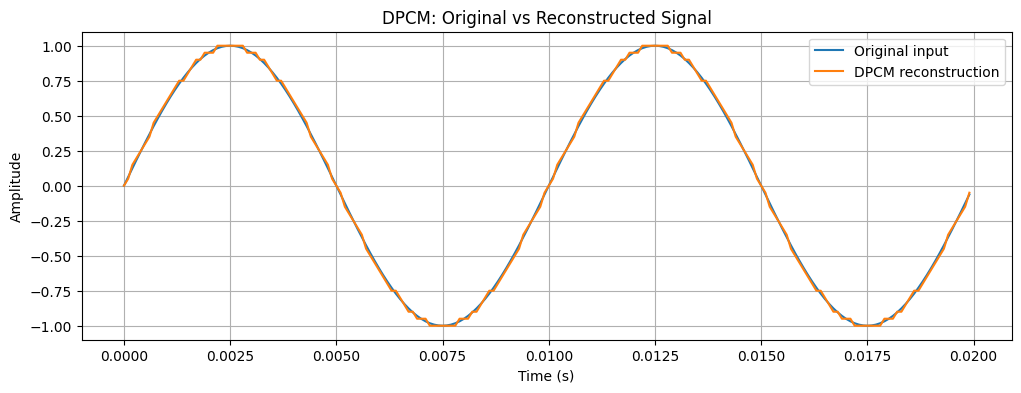


DPCM Results
--------------------------------
Quantizer step Δ = 0.05
DPCM MSE         = 0.00022823667770138924


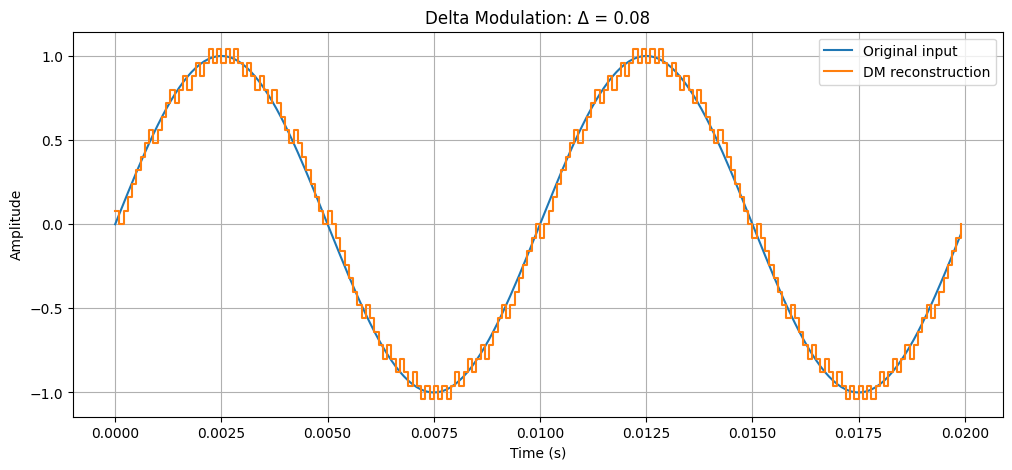

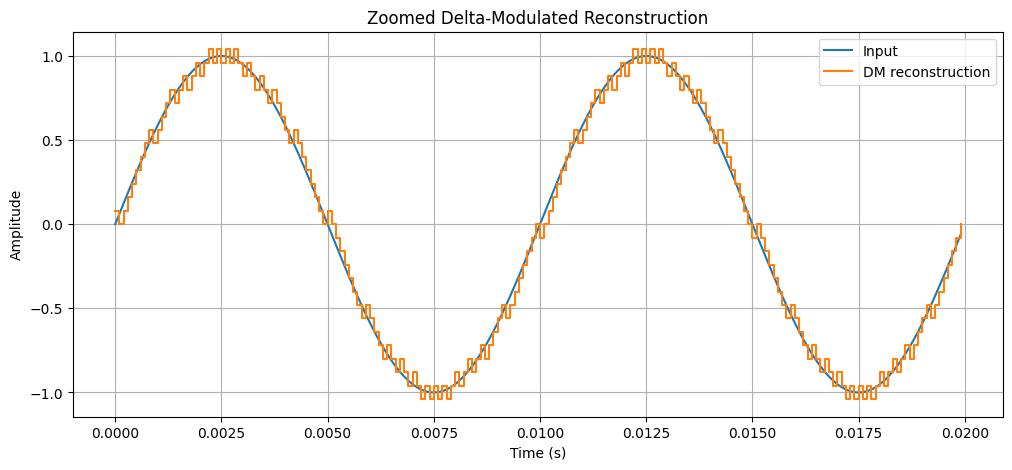


MANDATORY DELTA-MODULATION STEP VALIDATION
Expected step magnitudes = 0.08
Total number of steps = 199
Valid ±Δ steps = 199
Invalid steps = 0

✓ VALIDATION PASSED
Every output step changes by exactly +Δ or -Δ.

First 20 DM steps:


,n,Decision (+1/-1),Actual step,Expected step,Step error
0,1,-1,-0.080000,-0.080000,0.000e+00
1,2,1,0.080000,0.080000,0.000e+00
2,3,1,0.080000,0.080000,0.000e+00
3,4,1,0.080000,0.080000,-1.388e-17
4,5,1,0.080000,0.080000,1.388e-17
5,6,1,0.080000,0.080000,1.388e-17
6,7,1,0.080000,0.080000,1.388e-17
7,8,1,0.080000,0.080000,1.388e-17
8,9,-1,-0.080000,-0.080000,-1.388e-17
9,10,1,0.080000,0.080000,1.388e-17


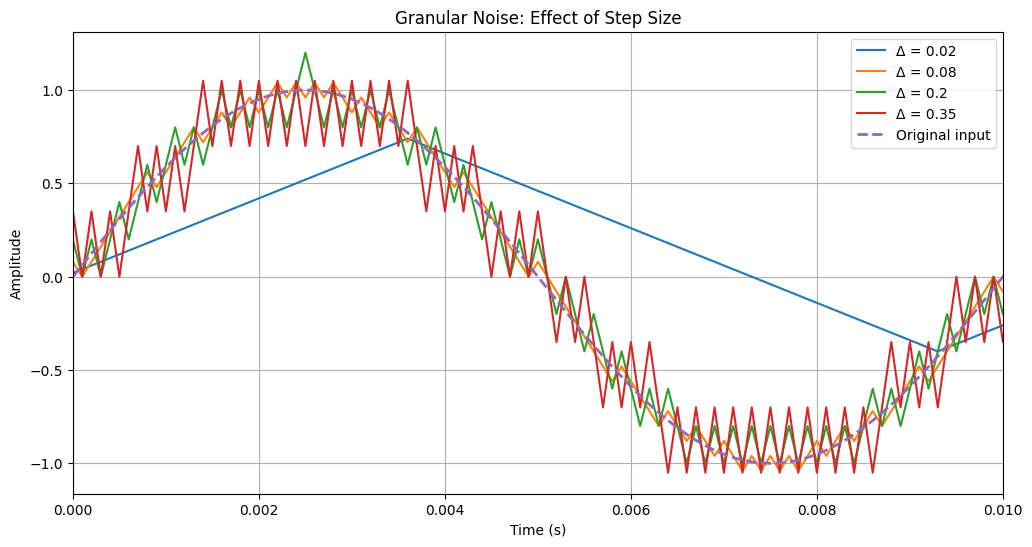


Granular Noise Analysis


,Step size Δ,MSE,RMSE
0,0.020,0.334855,0.578666
1,0.080,0.002149,0.046357
2,0.200,0.013943,0.118079
3,0.350,0.040256,0.200638


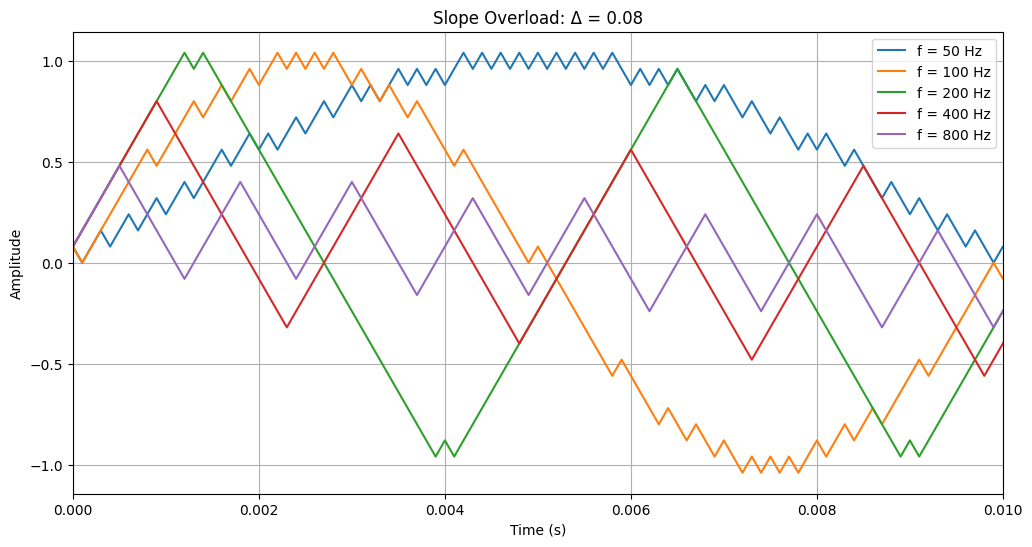

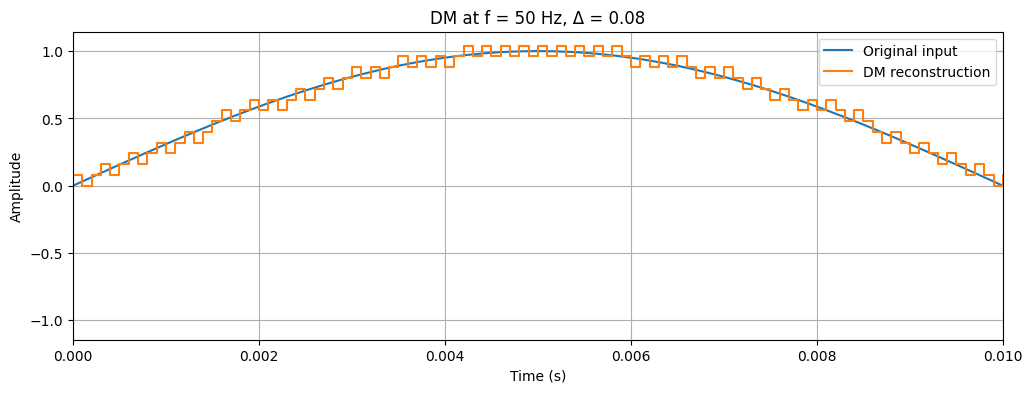

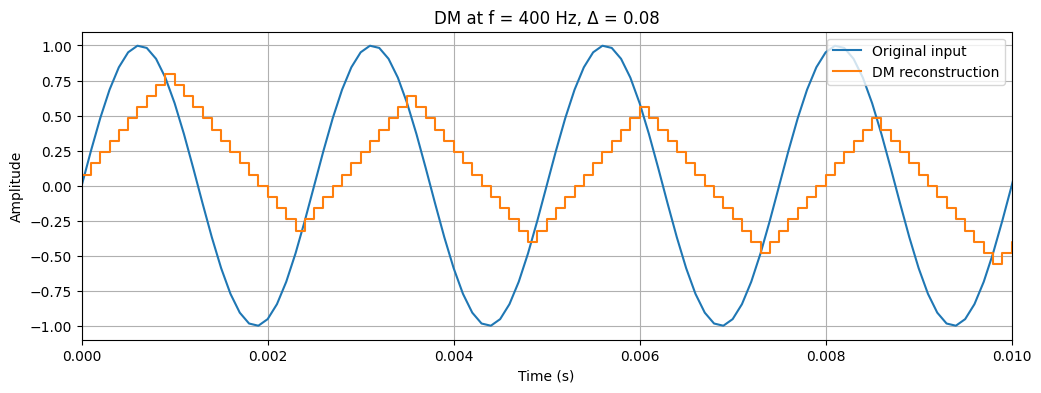

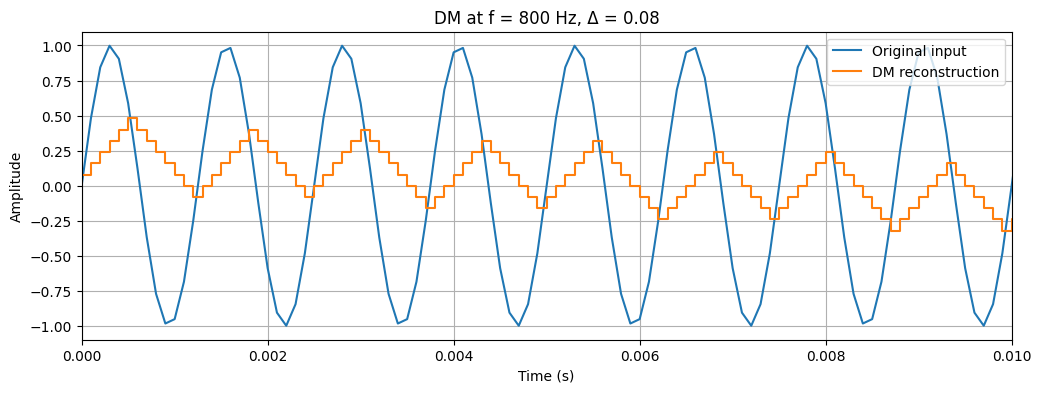


Slope Overload Analysis


,Frequency (Hz),Input max slope,DM max slope,MSE
0,50,314.159,800.000,0.002154
1,100,628.319,800.000,0.002149
2,200,1256.637,800.000,0.055014
3,400,2513.274,800.000,0.351439
4,800,5026.548,800.000,0.432109



Theoretical maximum frequency
for avoiding slope overload:
127.32395447351627 Hz


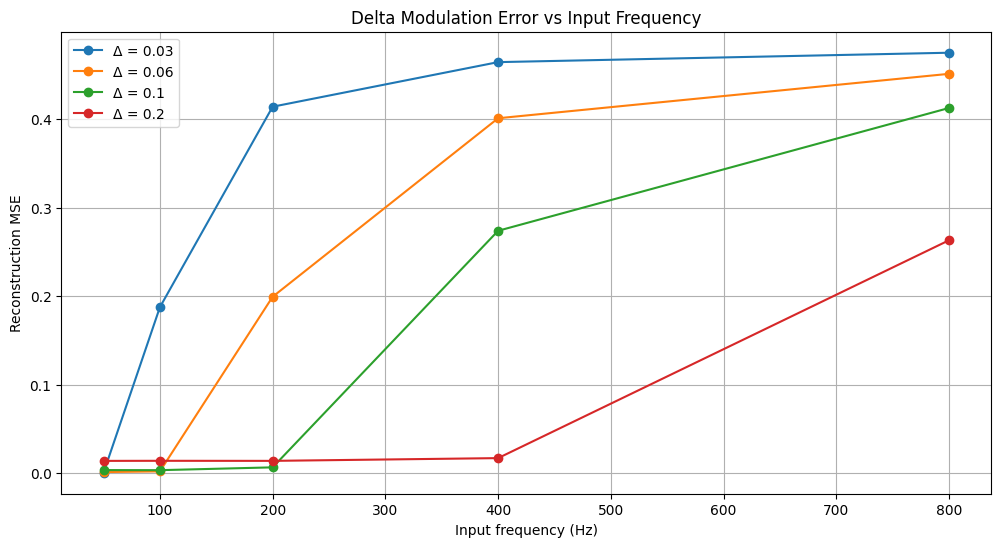


FINAL SUMMARY

DPCM:
    Prediction:
        x_hat[n] = reconstructed x[n-1]

    Prediction error:
        e[n] = x[n] - x_hat[n]

    Quantization:
        e_q[n] = Q(e[n])

    Reconstruction:
        x_r[n] = x_hat[n] + e_q[n]


Delta Modulation:
    Prediction:
        x_hat[n] = x_r[n-1]

    Quantization:
        q[n] = +1 or -1

    Reconstruction:
        x_r[n] = x_r[n-1] + q[n]Δ


GRANULAR NOISE:
    Occurs when Δ is relatively large.
    The reconstructed signal oscillates around
    the input instead of following it smoothly.


SLOPE OVERLOAD:
    Occurs when the input changes faster than the
    maximum staircase slope.

    Maximum DM slope:
        Δ × fs

    Maximum sine-wave slope:
        2πfA

    Approximate condition for avoiding overload:
        Δfs >= 2πfA


MANDATORY VALIDATION:
    Every Delta-Modulator output step was checked.

    Required:
        x_r[n] - x_r[n-1] = +Δ or -Δ

    The validation table reports:
        Actual step
        Expected step
  

In [1]:
# ============================================================
# FIRST-ORDER DPCM AND DELTA MODULATION SIMULATION
# Google Colab Ready
#
# Explicit blocks:
#   1. Prediction
#   2. Quantization
#   3. Reconstruction
#
# Demonstrates:
#   - Granular noise
#   - Slope overload
#   - Effect of step size
#   - Effect of input frequency
#
# Mandatory validation:
#   Delta-modulator output must change by exactly +Δ or -Δ
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# 1. COMMON PARAMETERS
# ============================================================

fs = 10000          # Sampling frequency
duration = 0.02     # Signal duration
t = np.arange(0, duration, 1/fs)

A = 1.0             # Input amplitude

print("================================================")
print("DPCM AND DELTA MODULATION SIMULATION")
print("================================================")
print("Sampling frequency =", fs, "Hz")
print("Duration            =", duration, "seconds")
print("Amplitude           =", A)


# ============================================================
# 2. INPUT SIGNAL
# ============================================================

def generate_sine(frequency, amplitude=A):
    return amplitude * np.sin(
        2 * np.pi * frequency * t
    )


# ============================================================
# 3. FIRST-ORDER DPCM
# ============================================================
#
# Prediction:
#
#       x_hat[n] = x_r[n-1]
#
# Prediction error:
#
#       e[n] = x[n] - x_hat[n]
#
# Quantization:
#
#       e_q[n] = Q(e[n])
#
# Reconstruction:
#
#       x_r[n] = x_hat[n] + e_q[n]
#
# ============================================================

def dpcm_simulation(
    x,
    delta=0.1,
    prediction_order=1
):

    N = len(x)

    # --------------------------------------------------------
    # Arrays for each explicit stage
    # --------------------------------------------------------

    prediction = np.zeros(N)

    prediction_error = np.zeros(N)

    quantized_error = np.zeros(N)

    reconstruction = np.zeros(N)

    # --------------------------------------------------------
    # Initial condition
    # --------------------------------------------------------

    reconstruction[0] = x[0]

    prediction[0] = 0

    prediction_error[0] = (
        x[0] - prediction[0]
    )

    quantized_error[0] = (
        delta *
        np.round(
            prediction_error[0] / delta
        )
    )

    reconstruction[0] = (
        prediction[0]
        +
        quantized_error[0]
    )

    # --------------------------------------------------------
    # First-order prediction
    # --------------------------------------------------------

    for n in range(1, N):

        # 1. Prediction
        prediction[n] = reconstruction[n-1]

        # 2. Prediction error
        prediction_error[n] = (
            x[n] - prediction[n]
        )

        # 3. Quantization
        quantized_error[n] = (
            delta *
            np.round(
                prediction_error[n] / delta
            )
        )

        # 4. Reconstruction
        reconstruction[n] = (
            prediction[n]
            +
            quantized_error[n]
        )

    return (
        prediction,
        prediction_error,
        quantized_error,
        reconstruction
    )


# ============================================================
# 4. DELTA MODULATION
# ============================================================
#
# Prediction:
#
#       x_hat[n] = x_r[n-1]
#
# Error:
#
#       e[n] = x[n] - x_hat[n]
#
# Quantizer:
#
#       q[n] = +1  if e[n] >= 0
#            = -1  if e[n] < 0
#
# Reconstruction:
#
#       x_r[n] = x_r[n-1] + q[n]Δ
#
# ============================================================

def delta_modulation(
    x,
    delta=0.1
):

    N = len(x)

    prediction = np.zeros(N)

    error = np.zeros(N)

    decision = np.zeros(N)

    reconstruction = np.zeros(N)

    # --------------------------------------------------------
    # Initial reconstruction
    # --------------------------------------------------------

    reconstruction[0] = 0

    # --------------------------------------------------------
    # Delta modulation loop
    # --------------------------------------------------------

    for n in range(N):

        # 1. Prediction
        if n == 0:
            prediction[n] = 0
        else:
            prediction[n] = reconstruction[n-1]

        # 2. Prediction error
        error[n] = (
            x[n] - prediction[n]
        )

        # 3. One-bit quantization
        if error[n] >= 0:
            decision[n] = +1
        else:
            decision[n] = -1

        # 4. Reconstruction
        reconstruction[n] = (
            prediction[n]
            +
            decision[n] * delta
        )

    return (
        prediction,
        error,
        decision,
        reconstruction
    )


# ============================================================
# 5. BASIC DPCM EXAMPLE
# ============================================================

f_dpcm = 100

x_dpcm = generate_sine(
    f_dpcm
)

(
    dpcm_prediction,
    dpcm_error,
    dpcm_quantized_error,
    dpcm_reconstruction
) = dpcm_simulation(
    x_dpcm,
    delta=0.05
)


# ============================================================
# 6. PLOT DPCM STAGES
# ============================================================

plt.figure(figsize=(12, 4))

plt.plot(
    t,
    x_dpcm,
    label="Original input"
)

plt.plot(
    t,
    dpcm_prediction,
    label="Prediction"
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("DPCM: Input and First-Order Prediction")
plt.grid(True)
plt.legend()

plt.show()


plt.figure(figsize=(12, 4))

plt.plot(
    t,
    dpcm_error,
    label="Prediction error"
)

plt.plot(
    t,
    dpcm_quantized_error,
    label="Quantized error"
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("DPCM: Prediction Error and Quantization")
plt.grid(True)
plt.legend()

plt.show()


plt.figure(figsize=(12, 4))

plt.plot(
    t,
    x_dpcm,
    label="Original input"
)

plt.plot(
    t,
    dpcm_reconstruction,
    label="DPCM reconstruction"
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("DPCM: Original vs Reconstructed Signal")
plt.grid(True)
plt.legend()

plt.show()


# ============================================================
# 7. DPCM QUANTIZATION ERROR
# ============================================================

dpcm_reconstruction_error = (
    x_dpcm -
    dpcm_reconstruction
)

dpcm_mse = np.mean(
    dpcm_reconstruction_error**2
)

print("\nDPCM Results")
print("--------------------------------")
print("Quantizer step Δ =", 0.05)
print("DPCM MSE         =", dpcm_mse)


# ============================================================
# 8. DELTA MODULATION EXAMPLE
# ============================================================

f_dm = 100
delta_dm = 0.08

x_dm = generate_sine(
    f_dm
)

(
    dm_prediction,
    dm_error,
    dm_decision,
    dm_reconstruction
) = delta_modulation(
    x_dm,
    delta=delta_dm
)


# ============================================================
# 9. PLOT DELTA MODULATION
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    t,
    x_dm,
    label="Original input"
)

plt.step(
    t,
    dm_reconstruction,
    where="post",
    label="DM reconstruction"
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(
    f"Delta Modulation: Δ = {delta_dm}"
)

plt.grid(True)
plt.legend()

plt.show()


# ============================================================
# 10. ZOOMED DM OUTPUT
# ============================================================

zoom_samples = 250

plt.figure(figsize=(12, 5))

plt.plot(
    t[:zoom_samples],
    x_dm[:zoom_samples],
    label="Input"
)

plt.step(
    t[:zoom_samples],
    dm_reconstruction[:zoom_samples],
    where="post",
    label="DM reconstruction"
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.title(
    "Zoomed Delta-Modulated Reconstruction"
)

plt.grid(True)
plt.legend()

plt.show()


# ============================================================
# 11. MANDATORY VALIDATION
# ============================================================
#
# Every DM reconstruction step MUST change by exactly:
#
#               +Δ  OR  -Δ
#
# ============================================================

dm_steps = np.diff(
    dm_reconstruction
)

expected_steps = (
    delta_dm *
    dm_decision[1:]
)

step_error = (
    dm_steps -
    expected_steps
)

validation = pd.DataFrame({

    "n": np.arange(
        1,
        len(dm_reconstruction)
    ),

    "Decision (+1/-1)": dm_decision[1:],

    "Actual step": dm_steps,

    "Expected step": expected_steps,

    "Step error": step_error

})


# ------------------------------------------------------------
# Check exact ±Δ property
# ------------------------------------------------------------

tolerance = 1e-12

valid_steps = np.isclose(
    np.abs(dm_steps),
    delta_dm,
    atol=tolerance
)

invalid_steps = np.where(
    ~valid_steps
)[0]


print("\n================================================")
print("MANDATORY DELTA-MODULATION STEP VALIDATION")
print("================================================")

print(
    "Expected step magnitudes =",
    delta_dm
)

print(
    "Total number of steps =",
    len(dm_steps)
)

print(
    "Valid ±Δ steps =",
    np.sum(valid_steps)
)

print(
    "Invalid steps =",
    len(invalid_steps)
)

if len(invalid_steps) == 0:

    print(
        "\n✓ VALIDATION PASSED"
    )

    print(
        "Every output step changes by exactly +Δ or -Δ."
    )

else:

    print(
        "\n✗ VALIDATION FAILED"
    )

    print(
        "Some output steps are not equal to ±Δ."
    )


# Display first 20 validation samples

print("\nFirst 20 DM steps:")

display(
    validation.head(20).style.format({
        "Decision (+1/-1)": "{:.0f}",
        "Actual step": "{:.6f}",
        "Expected step": "{:.6f}",
        "Step error": "{:.3e}"
    })
)


# ============================================================
# 12. GRANULAR NOISE DEMONSTRATION
# ============================================================
#
# Large Δ compared with the signal variation
# causes granular noise.
# ============================================================

f_granular = 100

x_granular = generate_sine(
    f_granular
)

granular_steps = [
    0.02,
    0.08,
    0.20,
    0.35
]

plt.figure(figsize=(12, 6))

for delta in granular_steps:

    (
        _,
        _,
        _,
        reconstruction
    ) = delta_modulation(
        x_granular,
        delta=delta
    )

    plt.plot(
        t,
        reconstruction,
        label=f"Δ = {delta}"
    )

plt.plot(
    t,
    x_granular,
    linestyle="--",
    linewidth=2,
    label="Original input"
)

plt.xlim(
    0,
    0.01
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.title(
    "Granular Noise: Effect of Step Size"
)

plt.grid(True)
plt.legend()

plt.show()


# ============================================================
# 13. CALCULATE GRANULAR-NOISE MSE
# ============================================================

granular_results = []

for delta in granular_steps:

    (
        _,
        _,
        _,
        reconstruction
    ) = delta_modulation(
        x_granular,
        delta=delta
    )

    error = (
        x_granular -
        reconstruction
    )

    mse = np.mean(
        error**2
    )

    granular_results.append({

        "Step size Δ": delta,

        "MSE": mse,

        "RMSE": np.sqrt(mse)

    })


granular_table = pd.DataFrame(
    granular_results
)

print("\nGranular Noise Analysis")

display(
    granular_table.style.format({
        "Step size Δ": "{:.3f}",
        "MSE": "{:.6f}",
        "RMSE": "{:.6f}"
    })
)


# ============================================================
# 14. SLOPE OVERLOAD DEMONSTRATION
# ============================================================
#
# Slope overload occurs when:
#
#       Δ * fs < maximum input slope
#
# For x(t)=A sin(2πft):
#
#       maximum slope = 2πfA
#
# Therefore slope overload occurs approximately when:
#
#       Δfs < 2πfA
#
# ============================================================

delta_slope = 0.08

frequencies = [
    50,
    100,
    200,
    400,
    800
]

plt.figure(figsize=(12, 6))

for frequency in frequencies:

    x = generate_sine(
        frequency
    )

    (
        _,
        _,
        _,
        reconstruction
    ) = delta_modulation(
        x,
        delta=delta_slope
    )

    plt.plot(
        t,
        reconstruction,
        label=f"f = {frequency} Hz"
    )

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.xlim(
    0,
    0.01
)

plt.title(
    f"Slope Overload: Δ = {delta_slope}"
)

plt.grid(True)
plt.legend()

plt.show()


# ============================================================
# 15. INDIVIDUAL SLOPE-OVERLOAD PLOTS
# ============================================================

for frequency in [
    50,
    400,
    800
]:

    x = generate_sine(
        frequency
    )

    (
        _,
        _,
        _,
        reconstruction
    ) = delta_modulation(
        x,
        delta=delta_slope
    )

    plt.figure(figsize=(12, 4))

    plt.plot(
        t,
        x,
        label="Original input"
    )

    plt.step(
        t,
        reconstruction,
        where="post",
        label="DM reconstruction"
    )

    plt.xlim(
        0,
        0.01
    )

    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")

    plt.title(
        f"DM at f = {frequency} Hz, Δ = {delta_slope}"
    )

    plt.grid(True)
    plt.legend()

    plt.show()


# ============================================================
# 16. SLOPE-OVERLOAD MSE VS FREQUENCY
# ============================================================

frequency_results = []

for frequency in frequencies:

    x = generate_sine(
        frequency
    )

    (
        _,
        _,
        _,
        reconstruction
    ) = delta_modulation(
        x,
        delta=delta_slope
    )

    error = (
        x -
        reconstruction
    )

    mse = np.mean(
        error**2
    )

    maximum_input_slope = (
        2*np.pi*frequency*A
    )

    maximum_DM_slope = (
        delta_slope * fs
    )

    frequency_results.append({

        "Frequency (Hz)": frequency,

        "Input max slope": maximum_input_slope,

        "DM max slope": maximum_DM_slope,

        "MSE": mse

    })


frequency_table = pd.DataFrame(
    frequency_results
)

print("\nSlope Overload Analysis")

display(
    frequency_table.style.format({
        "Frequency (Hz)": "{:.0f}",
        "Input max slope": "{:.3f}",
        "DM max slope": "{:.3f}",
        "MSE": "{:.6f}"
    })
)


# ============================================================
# 17. THEORETICAL SLOPE-OVERLOAD LIMIT
# ============================================================

maximum_frequency_without_slope_overload = (
    delta_slope * fs /
    (2*np.pi*A)
)

print(
    "\nTheoretical maximum frequency"
)

print(
    "for avoiding slope overload:"
)

print(
    f_max := maximum_frequency_without_slope_overload,
    "Hz"
)


# ============================================================
# 18. STEP SIZE VS FREQUENCY COMPARISON
# ============================================================

step_sizes = [
    0.03,
    0.06,
    0.10,
    0.20
]

test_frequencies = [
    50,
    100,
    200,
    400,
    800
]

mse_matrix = np.zeros(
    (
        len(step_sizes),
        len(test_frequencies)
    )
)

for i, delta in enumerate(step_sizes):

    for j, frequency in enumerate(test_frequencies):

        x = generate_sine(
            frequency
        )

        (
            _,
            _,
            _,
            reconstruction
        ) = delta_modulation(
            x,
            delta=delta
        )

        mse_matrix[i, j] = np.mean(
            (
                x -
                reconstruction
            )**2
        )


# ============================================================
# 19. PLOT MSE VS FREQUENCY
# ============================================================

plt.figure(figsize=(12, 6))

for i, delta in enumerate(step_sizes):

    plt.plot(
        test_frequencies,
        mse_matrix[i],
        marker="o",
        label=f"Δ = {delta}"
    )

plt.xlabel(
    "Input frequency (Hz)"
)

plt.ylabel(
    "Reconstruction MSE"
)

plt.title(
    "Delta Modulation Error vs Input Frequency"
)

plt.grid(True)
plt.legend()

plt.show()


# ============================================================
# 20. FINAL SUMMARY
# ============================================================

print("\n================================================")
print("FINAL SUMMARY")
print("================================================")

print("""
DPCM:
    Prediction:
        x_hat[n] = reconstructed x[n-1]

    Prediction error:
        e[n] = x[n] - x_hat[n]

    Quantization:
        e_q[n] = Q(e[n])

    Reconstruction:
        x_r[n] = x_hat[n] + e_q[n]


Delta Modulation:
    Prediction:
        x_hat[n] = x_r[n-1]

    Quantization:
        q[n] = +1 or -1

    Reconstruction:
        x_r[n] = x_r[n-1] + q[n]Δ


GRANULAR NOISE:
    Occurs when Δ is relatively large.
    The reconstructed signal oscillates around
    the input instead of following it smoothly.


SLOPE OVERLOAD:
    Occurs when the input changes faster than the
    maximum staircase slope.

    Maximum DM slope:
        Δ × fs

    Maximum sine-wave slope:
        2πfA

    Approximate condition for avoiding overload:
        Δfs >= 2πfA


MANDATORY VALIDATION:
    Every Delta-Modulator output step was checked.

    Required:
        x_r[n] - x_r[n-1] = +Δ or -Δ

    The validation table reports:
        Actual step
        Expected step
        Step error
""")